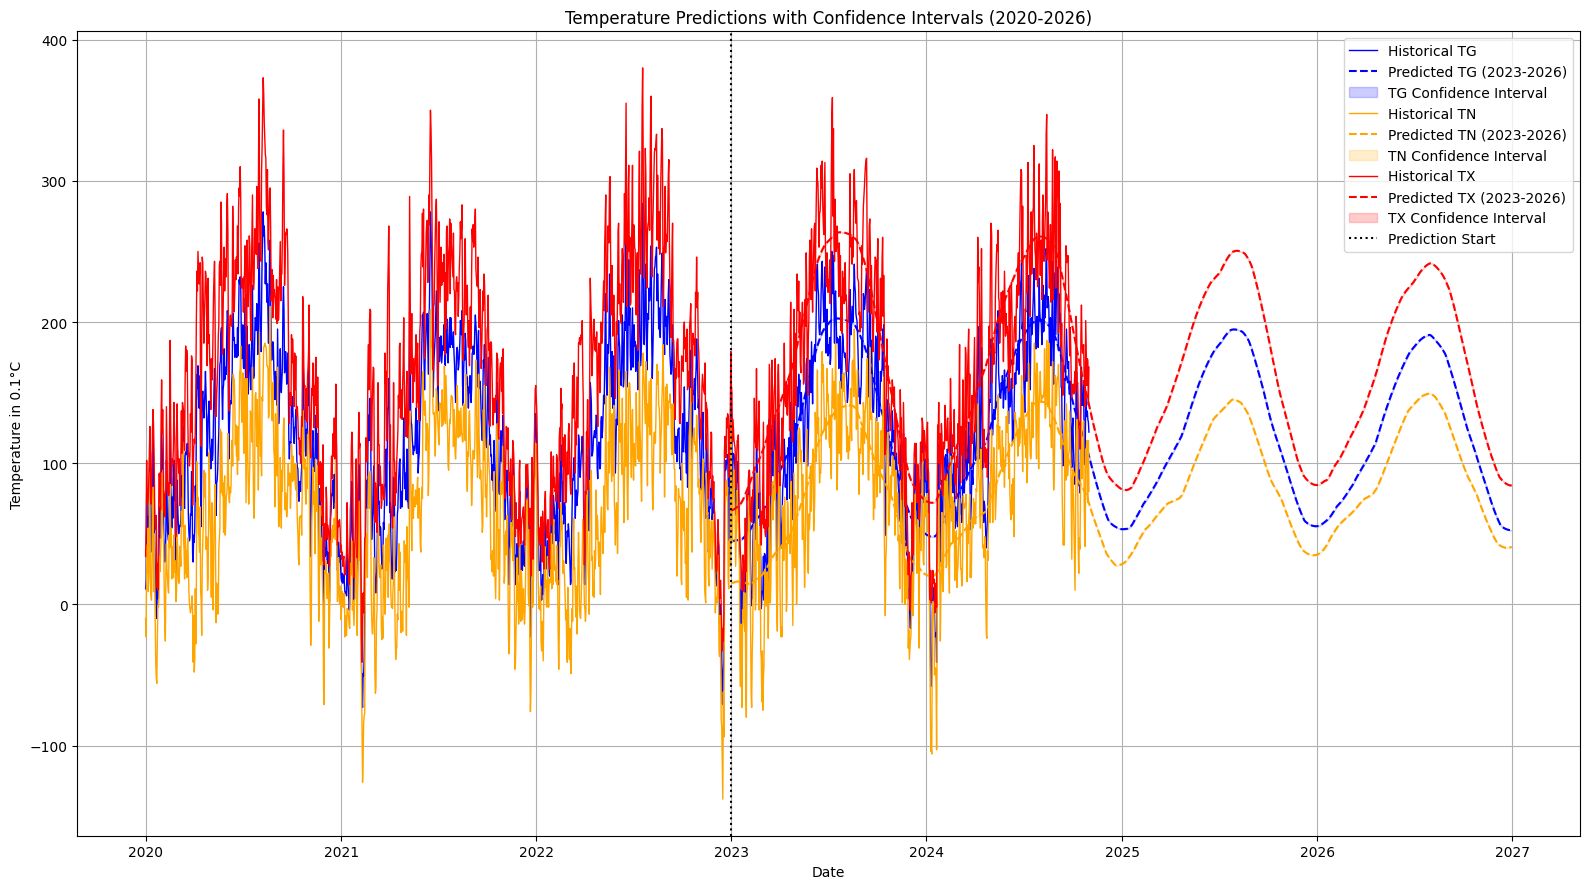

In [3]:
import pandas as pd
import numpy as np
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# File paths
file_tg_path = 'TG_SOUID121044.txt'
file_tn_path = 'TN_SOUID121045.txt'
file_tx_path = 'TX_SOUID121046.txt'

# Function to load and process data
def load_and_process(file_path, temp_col, quality_col):
    with open(file_path, 'r') as file:
        lines = file.readlines()

    # Identify data start
    data_start_index = next(i for i, line in enumerate(lines) if "SOUID" in line and "DATE" in line) + 1

    # Extract relevant data
    data_lines = lines[data_start_index:]
    data = []
    for line in data_lines:
        parts = line.split(",")
        if len(parts) >= 4:
            data.append([parts[0].strip(), parts[1].strip(), parts[2].strip(), parts[3].strip()])

    # Create DataFrame
    columns = ["SOUID", "DATE", temp_col, quality_col]
    df = pd.DataFrame(data, columns=columns)

    # Convert to appropriate types
    df[temp_col] = pd.to_numeric(df[temp_col], errors='coerce')
    df[quality_col] = pd.to_numeric(df[quality_col], errors='coerce')

    # Filter valid data
    df = df[df[quality_col] == 0]
    df["DATE"] = pd.to_datetime(df["DATE"], format='%Y%m%d')

    # Filter data from 2020 onwards
    df = df[df["DATE"] >= "2020-01-01"]
    return df

# Load datasets
tg_data = load_and_process(file_tg_path, "TG", "Q_TG")
tn_data = load_and_process(file_tn_path, "TN", "Q_TN")
tx_data = load_and_process(file_tx_path, "TX", "Q_TX")

# Combine datasets
combined_data = pd.merge(tg_data[["DATE", "TG"]], tn_data[["DATE", "TN"]], on="DATE")
combined_data = pd.merge(combined_data, tx_data[["DATE", "TX"]], on="DATE")

# Prepare for MLP fitting
X = (combined_data["DATE"] - pd.Timestamp("2020-01-01")).dt.days.values.reshape(-1, 1)

# Adding periodic features
X_periodic = np.hstack([
    X,
    np.sin(2 * np.pi * X / 365.25),  # Annual cycle
    np.cos(2 * np.pi * X / 365.25)
])

# Scale features
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X_periodic)

# Initialize plot
plt.figure(figsize=(16, 9))

# Loop through each temperature variable
for variable, color in zip(["TG", "TN", "TX"], ["blue", "orange", "red"]):
    # Prepare data for the current variable
    y = combined_data[variable].values
    y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

    # Train MLP
    mlp = MLPRegressor(hidden_layer_sizes=(50,), max_iter=5000, random_state=42)
    mlp.fit(X_scaled, y_scaled)

    # Historical predictions
    y_pred_scaled = mlp.predict(X_scaled)
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

    # Residuals and error calculation
    residuals = y - scaler_y.inverse_transform(y_scaled.reshape(-1, 1)).ravel()
    std_dev = np.std(residuals)

    # Future predictions
    future_dates = pd.date_range(start="2023-01-01", end="2026-12-31")
    X_future = (future_dates - pd.Timestamp("2020-01-01")).days.values.reshape(-1, 1)
    X_future_periodic = np.hstack([
        X_future,
        np.sin(2 * np.pi * X_future / 365.25),
        np.cos(2 * np.pi * X_future / 365.25)
    ])
    X_future_scaled = scaler_X.transform(X_future_periodic)
    y_future_scaled = mlp.predict(X_future_scaled)
    y_future = scaler_y.inverse_transform(y_future_scaled.reshape(-1, 1)).ravel()

    # Upper and lower bounds
    upper_bound = y_future + std_dev
    lower_bound = y_future - std_dev

    # Plot historical and predicted data
    plt.plot(combined_data["DATE"], combined_data[variable], label=f"Historical {variable}", linestyle='-', linewidth=1, color=color)
    plt.plot(future_dates, y_future, label=f"Predicted {variable} (2023-2026)", linestyle='--', color=color)
    plt.fill_between(future_dates, lower_bound, upper_bound, color=color, alpha=0.2, label=f"{variable} Confidence Interval")

# Mark prediction start
plt.axvline(x=pd.Timestamp("2023-01-01"), color="black", linestyle=":", label="Prediction Start")

# Add titles and labels
plt.title("Temperature Predictions with Confidence Intervals (2020-2026)")
plt.xlabel("Date")
plt.ylabel("Temperature in 0.1°C")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Show plot
plt.show()
